In [1]:
'''
TEST VERİLERİ
total_tests / new_tests	Toplam/günlük yapılan test sayısı
positive_rate	pozitif testlerin tüm testlere oranı
(yüksekse muhtemelen yeterince test yapılmıyor demektir)
tests_per_case	Bir vaka bulmak için kaç test yapıldı
tests_units	Test sayımının birimi (kişi mi, test sayısı mı — bazı ülkeler farklı sayıyor)
'''

'\nTEST VERİLERİ\ntotal_tests / new_tests\tToplam/günlük yapılan test sayısı\npositive_rate\tpozitif testlerin tüm testlere oranı\n(yüksekse muhtemelen yeterince test yapılmıyor demektir)\ntests_per_case\tBir vaka bulmak için kaç test yapıldı\ntests_units\tTest sayımının birimi (kişi mi, test sayısı mı — bazı ülkeler farklı sayıyor)\n'

In [2]:
# Ortak yardımcı fonksiyonlarla temiz ülke verisini yüklüyor ve temel kalite kontrolünü yapıyoruz.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import (
    load_countries,
    print_country_data_overview
)

df_countries = load_countries()
print_country_data_overview(df_countries)


Satır-sütun sayısı: (331169, 67)
Ülke sayısı: 198
İlk tarih: 2020-01-01 00:00:00
Son tarih: 2024-08-14 00:00:00
Tekrarlayan ülke-tarih kaydı: 0


In [3]:
#ttest sütunlarını ve veri tiplerini kontrol ediyoruz
testing_columns = [
    'location',
    'date',
    'total_tests',
    'new_tests',
    'total_tests_per_thousand',
    'new_tests_per_thousand',
    'new_tests_smoothed',
    'new_tests_smoothed_per_thousand',
    'positive_rate',
    'tests_per_case',
    'tests_units'
]

print(df_countries[testing_columns].info())

display(df_countries[testing_columns].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331169 entries, 0 to 331168
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   location                         331169 non-null  object        
 1   date                             331169 non-null  datetime64[ns]
 2   total_tests                      76246 non-null   float64       
 3   new_tests                        72300 non-null   float64       
 4   total_tests_per_thousand         76246 non-null   float64       
 5   new_tests_per_thousand           72300 non-null   float64       
 6   new_tests_smoothed               100366 non-null  float64       
 7   new_tests_smoothed_per_thousand  100366 non-null  float64       
 8   positive_rate                    92583 non-null   float64       
 9   tests_per_case                   91122 non-null   float64       
 10  tests_units                      103115 non-

,location,date,total_tests,new_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,positive_rate,tests_per_case,tests_units
0,Afghanistan,2020-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,2020-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
testing_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_toplam_test_kaydi=('total_tests', 'count'),
        dolu_yeni_test_kaydi=('new_tests', 'count'),
        dolu_duzeltilmis_test_kaydi=(
            'new_tests_smoothed',
            'count'
        ),
        dolu_pozitiflik_kaydi=('positive_rate', 'count'),
        dolu_test_vaka_orani_kaydi=(
            'tests_per_case',
            'count'
        ),
        dolu_test_birimi_kaydi=('tests_units', 'count')
    )
)

testing_coverage['bos_yeni_test_kaydi'] = (
    testing_coverage['toplam_satir']
    - testing_coverage['dolu_yeni_test_kaydi']
)

testing_coverage['bos_pozitiflik_kaydi'] = (
    testing_coverage['toplam_satir']
    - testing_coverage['dolu_pozitiflik_kaydi']
)

testing_country_counts = pd.Series({
    'Toplam test verisi bulunan ülke': (
        testing_coverage['dolu_toplam_test_kaydi'].gt(0).sum()
    ),
    'Yeni test verisi bulunan ülke': (
        testing_coverage['dolu_yeni_test_kaydi'].gt(0).sum()
    ),
    'Düzeltilmiş test verisi bulunan ülke': (
        testing_coverage['dolu_duzeltilmis_test_kaydi'].gt(0).sum()
    ),
    'Pozitiflik oranı bulunan ülke': (
        testing_coverage['dolu_pozitiflik_kaydi'].gt(0).sum()
    ),
    'Test/vaka oranı bulunan ülke': (
        testing_coverage['dolu_test_vaka_orani_kaydi'].gt(0).sum()
    ),
    'Test birimi bilgisi bulunan ülke': (
        testing_coverage['dolu_test_birimi_kaydi'].gt(0).sum()
    )
})

print(testing_country_counts)

print(
    testing_coverage
    .sort_values('dolu_pozitiflik_kaydi', ascending=False)
    .head(20)
)

Toplam test verisi bulunan ülke         175
Yeni test verisi bulunan ülke           145
Düzeltilmiş test verisi bulunan ülke    173
Pozitiflik oranı bulunan ülke           166
Test/vaka oranı bulunan ülke            165
Test birimi bilgisi bulunan ülke        180
dtype: int64
                      toplam_satir  dolu_toplam_test_kaydi  \
location                                                     
Mexico                        1678                     900   
Taiwan                        1348                     888   
Malaysia                      1684                     878   
United Arab Emirates          1674                     846   
Argentina                     1678                     870   
Japan                         1674                     866   
Thailand                      1675                     882   
Israel                        1674                     854   
South Korea                   1674                     859   
Canada                        1674       

In [5]:
#hangi ülke teslerin nasıl değerlendirmiş.Test sayısına göre mi yapılan kişi sayına göre mi belirliyoruz.
test_unit_by_country = (
    df_countries.loc[
        df_countries['tests_units'].notna(),
        ['location', 'date', 'tests_units']
    ]
    .groupby('location')
    .agg(
        ilk_birim_tarihi=('date', 'min'),
        son_birim_tarihi=('date', 'max'),
        dolu_birim_kaydi=('tests_units', 'count'),
        farkli_test_birimi=('tests_units', 'nunique'),
        test_birimleri=(
            'tests_units',
            lambda values: ', '.join(
                sorted(values.dropna().unique())
            )
        )
    )
)

test_unit_summary = (
    df_countries.loc[
        df_countries['tests_units'].notna(),
        ['location', 'tests_units']
    ]
    .drop_duplicates()
    .groupby('tests_units')['location']
    .nunique()
    .sort_values(ascending=False)
)

print('Test birimine göre ülke sayısı:')
print(test_unit_summary)

print('\nBirden fazla test birimi görülen ülkeler:')
print(
    test_unit_by_country.loc[
        test_unit_by_country['farkli_test_birimi'] > 1
    ]
)

Test birimine göre ülke sayısı:
tests_units
tests performed    141
people tested       24
samples tested      14
units unclear        1
Name: location, dtype: int64

Birden fazla test birimi görülen ülkeler:
Empty DataFrame
Columns: [ilk_birim_tarihi, son_birim_tarihi, dolu_birim_kaydi, farkli_test_birimi, test_birimleri]
Index: []


In [6]:
#total_test nasıl değişmiş zaman içinde bunu kontrol ediyoruz
total_test_changes = (
    df_countries.loc[
        df_countries['total_tests'].notna(),
        ['location', 'date', 'total_tests']
    ]
    .sort_values(['location', 'date'])
    .copy()
)

total_test_changes['degisim'] = (
    total_test_changes
    .groupby('location')['total_tests']
    .diff()
)

total_test_decreases = total_test_changes.loc[
    total_test_changes['degisim'] < 0
]

print(
    'Toplam test sayısının azaldığı kayıt sayısı:',
    len(total_test_decreases)
)

print(total_test_decreases.to_string(index=False))

Toplam test sayısının azaldığı kayıt sayısı: 0
Empty DataFrame
Columns: [location, date, total_tests, degisim]
Index: []


In [7]:
#total_tests kayıtlarının veri setinde nerede olduğunu incelliyoruz
partial_total_test_missing = testing_coverage.loc[
    testing_coverage['dolu_toplam_test_kaydi'].gt(0)
    & testing_coverage['dolu_toplam_test_kaydi'].lt(
        testing_coverage['toplam_satir']
    )
].copy()

missing_total_test_rows = df_countries.loc[
    df_countries['location'].isin(
        partial_total_test_missing.index
    )
    & df_countries['total_tests'].isna(),
    ['location', 'date']
].copy()

valid_total_test_range = (
    df_countries.loc[
        df_countries['total_tests'].notna()
    ]
    .groupby('location')
    .agg(
        ilk_dolu_test_tarihi=('date', 'min'),
        son_dolu_test_tarihi=('date', 'max')
    )
)

missing_total_test_positions = missing_total_test_rows.join(
    valid_total_test_range,
    on='location'
)

missing_total_test_positions['bosluk_konumu'] = 'arada'

missing_total_test_positions.loc[
    missing_total_test_positions['date']
    < missing_total_test_positions['ilk_dolu_test_tarihi'],
    'bosluk_konumu'
] = 'başta'

missing_total_test_positions.loc[
    missing_total_test_positions['date']
    > missing_total_test_positions['son_dolu_test_tarihi'],
    'bosluk_konumu'
] = 'sonda'

total_test_missing_position_summary = (
    missing_total_test_positions
    .groupby(['location', 'bosluk_konumu'])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=['başta', 'arada', 'sonda'],
        fill_value=0
    )
)

print(total_test_missing_position_summary)

bosluk_konumu  başta  arada  sonda
location                          
Afghanistan      755    141    773
Albania           51    129    774
Algeria          792      0    881
Andorra          253    452    893
Angola           740    110    794
...              ...    ...    ...
Vanuatu          777      6    889
Vietnam          618    102    776
Yemen            783     86    803
Zambia            74     35    781
Zimbabwe         122    104    774

[175 rows x 3 columns]


In [8]:
#negatif günlük test verisi var mı,kontrol ediyoruz.
negative_new_tests = df_countries.loc[
    df_countries['new_tests'].lt(0),
    ['location', 'date', 'new_tests']
].sort_values(['location', 'date'])

print('Negatif yeni test kaydı sayısı:', len(negative_new_tests))
print(negative_new_tests.to_string(index=False))

Negatif yeni test kaydı sayısı: 0
Empty DataFrame
Columns: [location, date, new_tests]
Index: []


In [9]:
#new_tests değerlerinin olmadığı sütunlar başta,ortada,sonda ne kadar olduğunu tespit ediyoruz
partial_new_test_missing = testing_coverage.loc[
    testing_coverage['dolu_yeni_test_kaydi'].gt(0)
    & testing_coverage['dolu_yeni_test_kaydi'].lt(
        testing_coverage['toplam_satir']
    )
].copy()

missing_new_test_rows = df_countries.loc[
    df_countries['location'].isin(
        partial_new_test_missing.index
    )
    & df_countries['new_tests'].isna(),
    ['location', 'date']
].copy()

valid_new_test_range = (
    df_countries.loc[
        df_countries['new_tests'].notna()
    ]
    .groupby('location')
    .agg(
        ilk_dolu_yeni_test_tarihi=('date', 'min'),
        son_dolu_yeni_test_tarihi=('date', 'max')
    )
)

missing_new_test_positions = missing_new_test_rows.join(
    valid_new_test_range,
    on='location'
)

missing_new_test_positions['bosluk_konumu'] = 'arada'

missing_new_test_positions.loc[
    missing_new_test_positions['date']
    < missing_new_test_positions[
        'ilk_dolu_yeni_test_tarihi'
    ],
    'bosluk_konumu'
] = 'başta'

missing_new_test_positions.loc[
    missing_new_test_positions['date']
    > missing_new_test_positions[
        'son_dolu_yeni_test_tarihi'
    ],
    'bosluk_konumu'
] = 'sonda'

new_test_missing_position_summary = (
    missing_new_test_positions
    .groupby(['location', 'bosluk_konumu'])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=['başta', 'arada', 'sonda'],
        fill_value=0
    )
)

print(new_test_missing_position_summary)

bosluk_konumu  başta  arada  sonda
location                          
Albania           51    129    774
Angola           747     41    881
Argentina          0     16    792
Armenia           29     11    797
Australia         63      0    774
...              ...    ...    ...
United States     56      0    778
Uruguay           78      0    840
Vietnam          619     70    850
Zambia            75     60    781
Zimbabwe         123    109    808

[145 rows x 3 columns]


In [10]:
#ülkeler new_tests verisini her gün mü kaydetmiş
new_test_dates = (
    df_countries.loc[
        df_countries['new_tests'].notna(),
        ['location', 'date', 'new_tests']
    ]
    .sort_values(['location', 'date'])
    .copy()
)

new_test_dates['kayitlar_arasi_gun'] = (
    new_test_dates
    .groupby('location')['date']
    .diff()
    .dt.days
)

new_test_frequency = (
    new_test_dates
    .groupby('location')
    .agg(
        kayit_sayisi=('date', 'size'),
        ilk_kayit_tarihi=('date', 'min'),
        son_kayit_tarihi=('date', 'max'),
        ortanca_kayit_araligi=(
            'kayitlar_arasi_gun',
            'median'
        )
    )
    .sort_values('kayit_sayisi', ascending=False)
)

print(new_test_frequency.head(25))

                      kayit_sayisi ilk_kayit_tarihi son_kayit_tarihi  \
location                                                               
Mexico                         900       2020-01-01       2022-06-18   
Taiwan                         888       2020-01-16       2022-06-22   
Thailand                       882       2020-01-04       2022-06-04   
Malaysia                       878       2020-01-24       2022-06-19   
Argentina                      870       2020-01-01       2022-06-04   
Japan                          866       2020-02-05       2022-06-22   
South Korea                    859       2020-02-08       2022-06-15   
Denmark                        856       2020-02-02       2022-06-22   
Israel                         854       2020-02-20       2022-06-22   
Slovenia                       854       2020-02-02       2022-06-22   
Estonia                        848       2020-02-06       2022-06-21   
Italy                          847       2020-02-25       2022-0

In [11]:
daily_tests = df_countries[
    [
        'location',
        'date',
        'new_tests'
    ]
].copy()

daily_tests['hafta_baslangici'] = (
    daily_tests['date']
    - pd.to_timedelta(
        daily_tests['date'].dt.dayofweek,
        unit='D'
    )
)

weekly_tests = (
    daily_tests
    .groupby(
        ['location', 'hafta_baslangici'],
        as_index=False
    )
    .agg(
        mevcut_test_toplami=(
            'new_tests',
            lambda values: values.sum(min_count=1)
        ),
        kayitli_gun=('date', 'size'),
        dolu_gun=('new_tests', 'count')
    )
)

weekly_tests['eksik_gun'] = (
    7 - weekly_tests['dolu_gun']
)

weekly_tests['tam_hafta'] = (
    weekly_tests['dolu_gun'] == 7
)

weekly_tests['haftalik_yeni_test'] = (
    weekly_tests['mevcut_test_toplami']
    .where(weekly_tests['tam_hafta'])
)

weekly_tests['veri_durumu'] = (
    weekly_tests['dolu_gun'].astype(str)
    + '/7 gün test verisi'
)

weekly_tests.loc[
    weekly_tests['tam_hafta'],
    'veri_durumu'
] = 'Tam hafta'

print(
    weekly_tests[
        [
            'location',
            'hafta_baslangici',
            'mevcut_test_toplami',
            'dolu_gun',
            'eksik_gun',
            'tam_hafta',
            'haftalik_yeni_test',
            'veri_durumu'
        ]
    ]
    .head(15)
)

       location hafta_baslangici  mevcut_test_toplami  dolu_gun  eksik_gun  \
0   Afghanistan       2019-12-30                  NaN         0          7   
1   Afghanistan       2020-01-06                  NaN         0          7   
2   Afghanistan       2020-01-13                  NaN         0          7   
3   Afghanistan       2020-01-20                  NaN         0          7   
4   Afghanistan       2020-01-27                  NaN         0          7   
5   Afghanistan       2020-02-03                  NaN         0          7   
6   Afghanistan       2020-02-10                  NaN         0          7   
7   Afghanistan       2020-02-17                  NaN         0          7   
8   Afghanistan       2020-02-24                  NaN         0          7   
9   Afghanistan       2020-03-02                  NaN         0          7   
10  Afghanistan       2020-03-09                  NaN         0          7   
11  Afghanistan       2020-03-16                  NaN         0 

In [12]:
#tam hafta sayısı kısmen ve kısmen dolu hafta sayısının kaç tane olduğunu inceliyoruz
weekly_tests['kismen_dolu_hafta'] = (
    weekly_tests['dolu_gun'].gt(0)
    & ~weekly_tests['tam_hafta']
)

weekly_tests['veri_yok_hafta'] = (
    weekly_tests['dolu_gun'].eq(0)
)

weekly_test_coverage = (
    weekly_tests
    .groupby('location')
    .agg(
        toplam_hafta=('hafta_baslangici', 'size'),
        tam_hafta_sayisi=('tam_hafta', 'sum'),
        kismen_dolu_hafta_sayisi=(
            'kismen_dolu_hafta',
            'sum'
        ),
        veri_yok_hafta_sayisi=(
            'veri_yok_hafta',
            'sum'
        )
    )
)

print(
    weekly_test_coverage
    .sort_values('tam_hafta_sayisi', ascending=False)
    .head(20)
)

               toplam_hafta  tam_hafta_sayisi  kismen_dolu_hafta_sayisi  \
location                                                                  
Mexico                  240               127                         2   
Taiwan                  193               126                         2   
Malaysia                242               125                         1   
Thailand                240               124                         3   
South Korea             240               122                         2   
Slovenia                240               121                         5   
Israel                  240               121                         2   
Japan                   240               120                         5   
Belgium                 240               120                         1   
Finland                 240               120                         2   
Denmark                 240               120                         5   
Estonia                 2

In [13]:
#yapılan testlerde pozitiflik oranı 0-1 aralığında çıkan deper var mı kontrol ediyorzu
invalid_positive_rates = df_countries.loc[
    df_countries['positive_rate'].notna()
    & (
        df_countries['positive_rate'].lt(0)#0'dan küçük 
        | df_countries['positive_rate'].gt(1)#1'den büyük
    ),
    ['location', 'date', 'positive_rate']
].sort_values(['location', 'date'])

print(
    '0-1 aralığı dışındaki pozitiflik oranı kaydı:',
    len(invalid_positive_rates)
)

print(invalid_positive_rates.to_string(index=False))

0-1 aralığı dışındaki pozitiflik oranı kaydı: 0
Empty DataFrame
Columns: [location, date, positive_rate]
Index: []


In [14]:
#boş pozitif rate oranının başta mı ortada mı sonda mı olduğuna bakıyoruz
partial_positive_rate_missing = testing_coverage.loc[
    testing_coverage['dolu_pozitiflik_kaydi'].gt(0)
    & testing_coverage['dolu_pozitiflik_kaydi'].lt(
        testing_coverage['toplam_satir']
    )
].copy()

missing_positive_rate_rows = df_countries.loc[
    df_countries['location'].isin(
        partial_positive_rate_missing.index
    )
    & df_countries['positive_rate'].isna(),
    ['location', 'date']
].copy()

valid_positive_rate_range = (
    df_countries.loc[
        df_countries['positive_rate'].notna()
    ]
    .groupby('location')
    .agg(
        ilk_dolu_pozitiflik_tarihi=('date', 'min'),
        son_dolu_pozitiflik_tarihi=('date', 'max')
    )
)

missing_positive_rate_positions = (
    missing_positive_rate_rows
    .join(valid_positive_rate_range, on='location')
)

missing_positive_rate_positions['bosluk_konumu'] = 'arada'

missing_positive_rate_positions.loc[
    missing_positive_rate_positions['date']
    < missing_positive_rate_positions[
        'ilk_dolu_pozitiflik_tarihi'
    ],
    'bosluk_konumu'
] = 'başta'

missing_positive_rate_positions.loc[
    missing_positive_rate_positions['date']
    > missing_positive_rate_positions[
        'son_dolu_pozitiflik_tarihi'
    ],
    'bosluk_konumu'
] = 'sonda'

positive_rate_missing_position_summary = (
    missing_positive_rate_positions
    .groupby(['location', 'bosluk_konumu'])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=['başta', 'arada', 'sonda'],
        fill_value=0
    )
)

print(positive_rate_missing_position_summary)
    

bosluk_konumu        başta  arada  sonda
location                                
Afghanistan            762      0    773
Albania                 69      1    774
Andorra                260      1    893
Angola                 747      0    794
Antigua and Barbuda    274      1   1118
...                    ...    ...    ...
Vanuatu                784      0    889
Vietnam                625     28    834
Yemen                  790      0    803
Zambia                  81      0    781
Zimbabwe               129      0    774

[166 rows x 3 columns]


In [15]:
#tests_per_case değerini kontrol ediyoruz 0 veya negatif olamaz
invalid_tests_per_case = df_countries.loc[
    df_countries['tests_per_case'].notna()
    & df_countries['tests_per_case'].le(0),
    ['location', 'date', 'tests_per_case']
].sort_values(['location', 'date'])

print(
    'Sıfır veya negatif test/vaka oranı kaydı:',
    len(invalid_tests_per_case)
)

print(invalid_tests_per_case.to_string(index=False))

Sıfır veya negatif test/vaka oranı kaydı: 0
Empty DataFrame
Columns: [location, date, tests_per_case]
Index: []


In [16]:
testing_graph_coverage = (
    df_countries.loc[
        df_countries['positive_rate'].notna()
        & df_countries['new_tests_smoothed'].notna(),
        [
            'location',
            'date',
            'positive_rate',
            'new_tests_smoothed'
        ]
    ]
    .groupby('location')
    .agg(
        ilk_ortak_tarih=('date', 'min'),
        son_ortak_tarih=('date', 'max'),
        ortak_kayit_sayisi=('date', 'size')
    )
)

testing_graph_coverage['aktif_donem_gunu'] = (
    (
        testing_graph_coverage['son_ortak_tarih']
        - testing_graph_coverage['ilk_ortak_tarih']
    )
    .dt.days
    + 1
)

testing_graph_coverage['kapsam_orani_yuzde'] = (
    testing_graph_coverage['ortak_kayit_sayisi']
    / testing_graph_coverage['aktif_donem_gunu']
    * 100
)

testing_graph_coverage['test_birimi'] = (
    testing_graph_coverage.index.map(
        test_unit_by_country['test_birimleri']
    )
)

print(
    testing_graph_coverage
    .sort_values(
        [
            'kapsam_orani_yuzde',
            'ortak_kayit_sayisi'
        ],
        ascending=False
    )
    .head(20)
)

                     ilk_ortak_tarih son_ortak_tarih  ortak_kayit_sayisi  \
location                                                                   
Mexico                    2020-01-08      2022-06-18                 893   
Malaysia                  2020-01-31      2022-06-19                 871   
United Arab Emirates      2020-02-05      2022-06-23                 870   
Japan                     2020-02-12      2022-06-22                 862   
South Korea               2020-02-15      2022-06-15                 852   
Slovenia                  2020-02-26      2022-06-22                 848   
Israel                    2020-02-27      2022-06-22                 847   
Estonia                   2020-03-03      2022-06-21                 841   
Sri Lanka                 2020-02-27      2022-06-14                 839   
Finland                   2020-03-05      2022-06-20                 838   
Latvia                    2020-03-07      2022-06-22                 838   
Croatia     

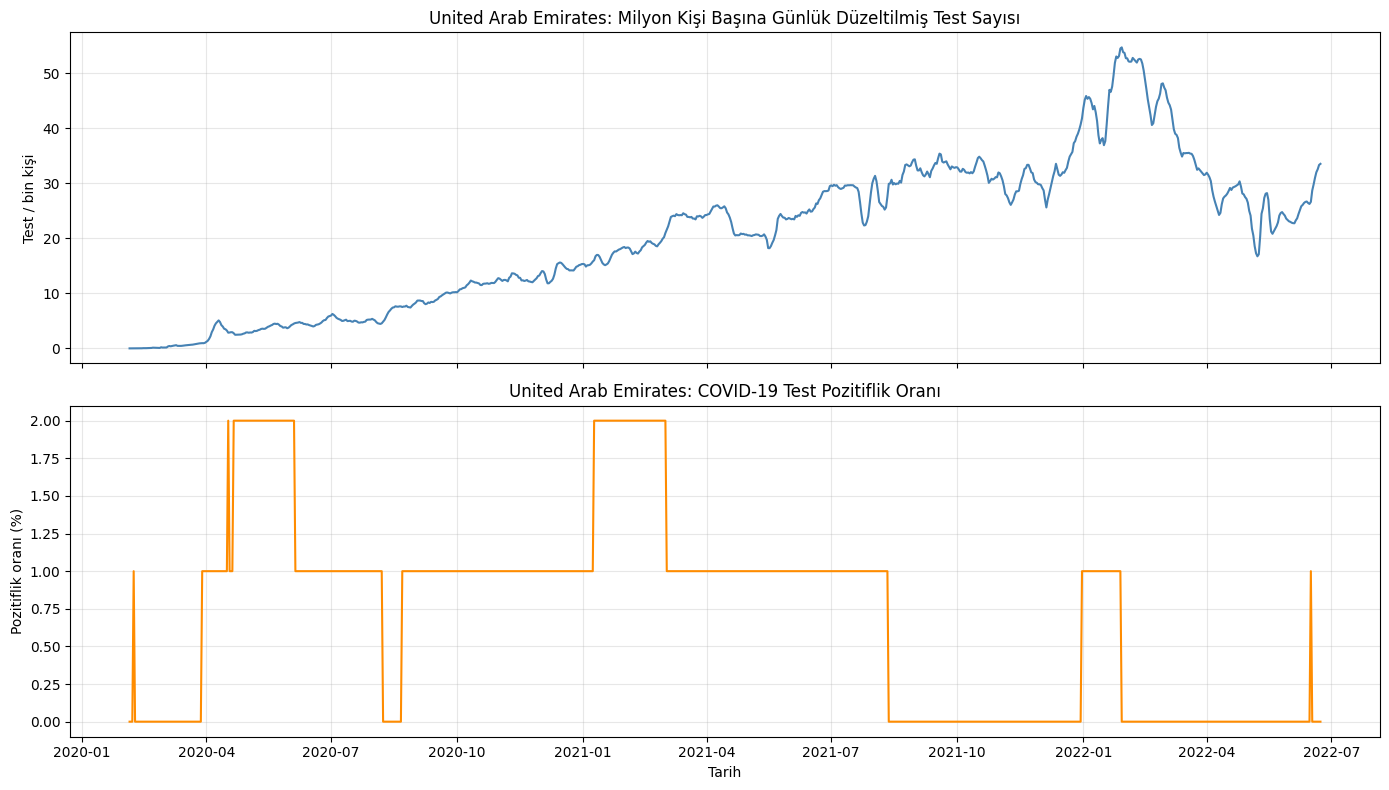

In [17]:
selected_testing_country = 'United Arab Emirates'

selected_testing_data = (
    df_countries.loc[
        (df_countries['location'] == selected_testing_country)
        & df_countries['positive_rate'].notna()
        & df_countries[
            'new_tests_smoothed_per_thousand'
        ].notna(),
        [
            'date',
            'new_tests_smoothed_per_thousand',
            'positive_rate'
        ]
    ]
    .sort_values('date')
    .copy()
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True
)

axes[0].plot(
    selected_testing_data['date'],
    selected_testing_data['new_tests_smoothed_per_thousand'],
    color='steelblue'
)

axes[0].set_title(
    f'{selected_testing_country}: Milyon Kişi Başına Günlük Düzeltilmiş Test Sayısı'
)

axes[0].set_ylabel('Test / bin kişi')
axes[0].grid(alpha=0.3)

axes[1].plot(
    selected_testing_data['date'],
    selected_testing_data['positive_rate'] * 100,
    color='darkorange'
)

axes[1].set_title(
    f'{selected_testing_country}: COVID-19 Test Pozitiflik Oranı'
)

axes[1].set_xlabel('Tarih')
axes[1].set_ylabel('Pozitiflik oranı (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Tüm ülkelerde ortak pozitiflik oranı sayısı: 138
Karşılaştırmada kullanılan tests performed ülke sayısı: 108


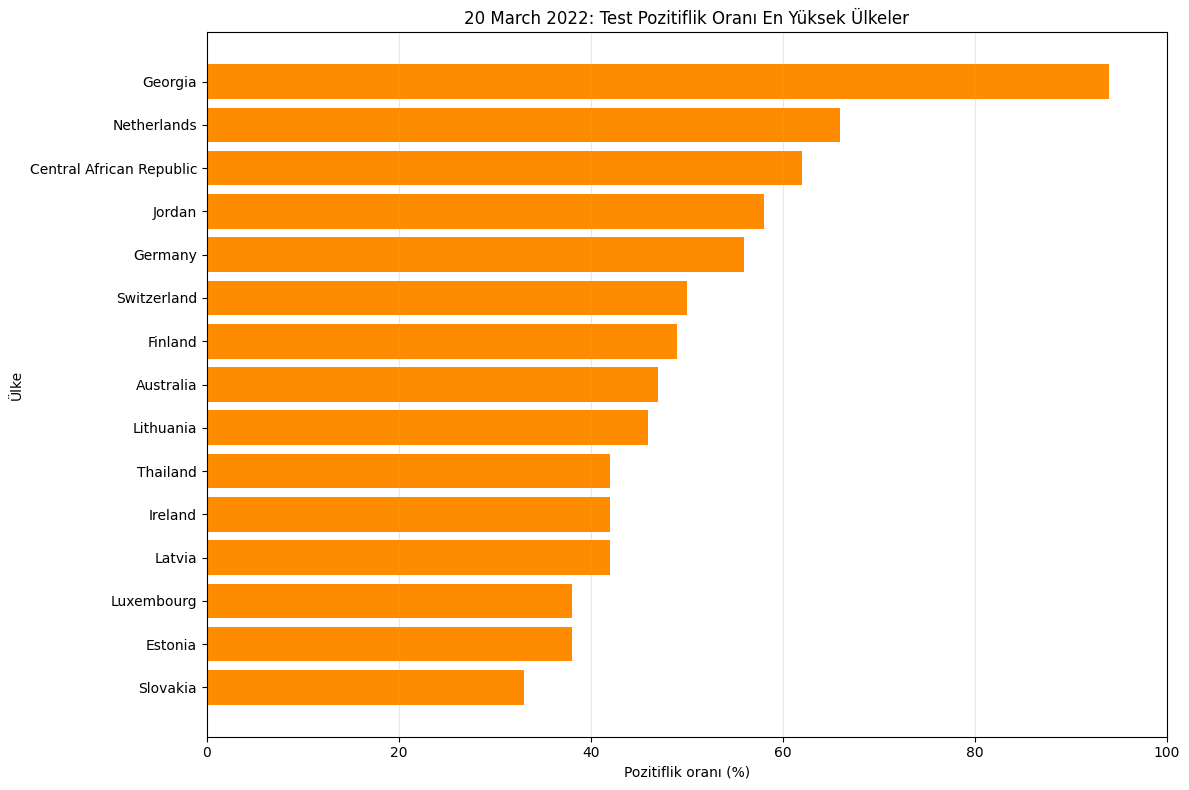

In [18]:
#aynı tarihlrde ülkelerin poztifilik oranı nasıl değişmiş inceliyoruz
#ülkeleri daha iyi karşılaştırmak için sadece test_performed birimini kullanan ülkeleri seçeceğiz
positive_rate_data = df_countries.loc[
    df_countries['positive_rate'].notna(),
    [
        'location',
        'date',
        'positive_rate',
        'tests_units'
    ]
].copy()

positive_rate_date_coverage = (
    positive_rate_data
    .groupby('date')['location']
    .nunique()
)

max_positive_country_count = (
    positive_rate_date_coverage.max()
)

positive_comparison_date = (
    positive_rate_date_coverage[
        positive_rate_date_coverage
        == max_positive_country_count
    ]
    .index
    .max()
)

positive_rate_snapshot = (
    positive_rate_data.loc[
        (positive_rate_data['date'] == positive_comparison_date)
        & (
            positive_rate_data['tests_units']
            == 'tests performed'
        ),
        [
            'location',
            'positive_rate'
        ]
    ]
    .sort_values('positive_rate', ascending=False)
    .head(15)
    .copy()
)

positive_rate_snapshot['pozitiflik_yuzde'] = (
    positive_rate_snapshot['positive_rate'] * 100
)

print(
    'Tüm ülkelerde ortak pozitiflik oranı sayısı:',
    max_positive_country_count
)

print(
    'Karşılaştırmada kullanılan tests performed ülke sayısı:',
    len(
        positive_rate_data.loc[
            (positive_rate_data['date'] == positive_comparison_date)
            & (
                positive_rate_data['tests_units']
                == 'tests performed'
            )
        ]
    )
)

plt.figure(figsize=(12, 8))

plt.barh(
    positive_rate_snapshot['location'],
    positive_rate_snapshot['pozitiflik_yuzde'],
    color='darkorange'
)

plt.gca().invert_yaxis()

plt.title(
    f'{positive_comparison_date:%d %B %Y}: Test Pozitiflik Oranı En Yüksek Ülkeler'
)

plt.xlabel('Pozitiflik oranı (%)')
plt.ylabel('Ülke')
plt.xlim(0, 100)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
from pathlib import Path

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Proje kök klasörü bulunamadı.')

PROJECT_ROOT = find_project_root()

# Haftalık test tablosunu kaydediyoruz
weekly_tests_final = (
    weekly_tests
    .merge(
        test_unit_by_country[['test_birimleri']],
        left_on='location',
        right_index=True,
        how='left'
    )
    .rename(columns={'test_birimleri': 'test_birimi'})
    .copy()
)

weekly_tests_final['hafta_sonu'] = weekly_tests_final['hafta_baslangici'] + pd.Timedelta(days=6)

processed_path = PROJECT_ROOT / 'data' / 'processed'
processed_path.mkdir(parents=True, exist_ok=True)
output_path = processed_path / 'weekly_tests.csv'

weekly_tests_final.to_csv(output_path, index=False)
print('Haftalık test tablosu kaydedildi:', output_path.name)

print(
    weekly_tests_final[
        [
            'location',
            'hafta_baslangici',
            'hafta_sonu',
            'haftalik_yeni_test',
            'tam_hafta',
            'veri_durumu',
            'test_birimi'
        ]
    ].head(15)
)


Haftalık test tablosu kaydedildi: weekly_tests.csv
       location hafta_baslangici hafta_sonu  haftalik_yeni_test  tam_hafta  \
0   Afghanistan       2019-12-30 2020-01-05                 NaN      False   
1   Afghanistan       2020-01-06 2020-01-12                 NaN      False   
2   Afghanistan       2020-01-13 2020-01-19                 NaN      False   
3   Afghanistan       2020-01-20 2020-01-26                 NaN      False   
4   Afghanistan       2020-01-27 2020-02-02                 NaN      False   
5   Afghanistan       2020-02-03 2020-02-09                 NaN      False   
6   Afghanistan       2020-02-10 2020-02-16                 NaN      False   
7   Afghanistan       2020-02-17 2020-02-23                 NaN      False   
8   Afghanistan       2020-02-24 2020-03-01                 NaN      False   
9   Afghanistan       2020-03-02 2020-03-08                 NaN      False   
10  Afghanistan       2020-03-09 2020-03-15                 NaN      False   
11  Afghanist

## Bulgular ve Dashboard Kararları

### Veri kapsamı ve test birimleri

- `total_tests` 172 ülkede, `new_tests` 142 ülkede, `new_tests_smoothed` 169 ülkede ve `positive_rate` 162 ülkede bulunmaktadır.
- Test birimi bilgisi 176 ülkede vardır.
- 138 ülke `tests performed`, 23 ülke `people tested`, 14 ülke `samples tested` ve 1 ülke `units unclear` test birimini kullanmaktadır.
- Hiçbir ülkede zaman içinde birden fazla test birimi görülmemiştir. Bu nedenle her ülkenin kendi zaman serisinde test ölçüm birimi tutarlıdır.
- Farklı test birimleri aynı ölçümü temsil etmediği için ham `total_tests` ve `new_tests` değerleri bütün ülkeler arasında doğrudan karşılaştırılmamalıdır.

### Toplam ve günlük test verisi

- `total_tests` kümülatif test sayısında azalış görülmemiştir. Test verisi bulunan dönemlerde kümülatif toplamlar mantıksal olarak artmaktadır.
- `total_tests` ve `new_tests` boşluklarının çoğu veri serisinin başlangıç veya bitiş döneminde bulunur. Aktif raporlama dönemindeki boşluklar sınırlıdır.
- `new_tests` alanında negatif değer bulunmamıştır.
- `new_tests` verisi bulunan 142 ülkenin 122’sinde kayıtlar çoğunlukla günlük aralıklarla paylaşılmıştır.
- Daha seyrek raporlama yapan veya yalnızca az sayıda test kaydı bulunan ülkeler de vardır. Bu nedenle haftalık test toplamları yalnızca 7 günün tamamında `new_tests` verisi bulunan haftalar için hesaplanmıştır.
- Eksik gün içeren haftalar sıfırla doldurulmamış, `tam_hafta` ve `veri_durumu` alanlarıyla etiketlenmiştir.

### Pozitiflik oranı ve test/vaka oranı

- `positive_rate` değerlerinin tamamı 0–1 aralığındadır; mantıksal sınır dışında değer bulunmamıştır.
- Pozitiflik oranı eksikliklerinin çoğu raporlamanın başlangıç veya bitiş dönemindedir. Aktif dönem içindeki boşluklar sınırlı olduğundan seçili ülke zaman grafikleri için uygundur.
- `tests_per_case` alanında sıfır veya negatif değer bulunmamıştır.
- Seçili ülke örneğinde bazı dönemlerde test yoğunluğu düşerken pozitiflik oranı yükselmiştir. Bu durum testlerin daha çok riskli kişilere uygulanması, test kapasitesi veya artan bulaş ile ilişkili olabilir; grafik tek başına nedensellik göstermez.

### Ülkeler arası karşılaştırma ve dashboard

- Pozitiflik oranı, ham test sayısına göre ülkeler arasında daha uygun bir karşılaştırma göstergesidir.
- En fazla ortak pozitiflik oranı bulunan tarih 20 Mart 2022’dir; bu tarihte 136 ülkenin pozitiflik oranı bulunmaktadır.
- Karşılaştırma grafiğinde yalnızca `tests performed` kullanan 107 ülke kullanılmıştır.
- Seçili ülke zaman grafiğinde milyon kişi başına düzeltilmiş test yoğunluğu ile pozitiflik oranı ayrı panellerde gösterilmiştir.
- Dashboard için `weekly_tests.csv` tablosu oluşturulmuştur. Haftalık test kartı yalnızca `tam_hafta = True` olan kayıtlarda kullanılmalıdır.
- Test birimi, veri durumu ve son gözlem tarihi dashboard’da kullanıcıya gösterilmelidir.